
Assignment:06  

Mega Assignment: Exploratory Data Analysis (EDA)  

Subrata Howlader

Dataset: Kaggle House Prices - Advanced Regression Techniques -  

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data  


Project Title: Unlocking Real Estate Value: A Comprehensive EDA of House Prices  









Phase 1: Data Inspection & Structural Audit  
Before plotting, you must understand the "skeleton" of your data.  
 Load & Glimpse: Import the data using Pandas. Display the first 10 rows and use .info() to identify column names and data types.  
 Variable Categorization: Create two lists: numerical_features and categorical_features.  
 The Target Variable: Perform a univariate analysis on SalePrice.  
o Calculate mean, median, skewness, and kurtosis.  
o Task: Plot a histogram and a Q-Q plot. Does it follow a normal distribution? If not, apply a log transformation.   


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, probplot

In [11]:
data = pd.read_csv("/content/train.csv")
print(data.head(10))

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    AllPub  ...       

In [12]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [26]:
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = data.select_dtypes(include=['object']).columns.tolist()

In [27]:
numerical_features.remove('SalePrice')

In [28]:
print("\nNumerical Features:", numerical_features)


Numerical Features: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [29]:
print("\nCategorical Features:", categorical_features)


Categorical Features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [31]:
saleprice = data['SalePrice']

In [32]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [36]:
mean_price = saleprice.mean()
median_price = saleprice.median()
skewness_price = skew(saleprice)
kurtosis_price = kurtosis(saleprice)

print("\nSalePrice Statistics:")
print(f"Mean: {mean_price:.2f}")
print(f"Median: {median_price:.2f}")
print(f"Skewness: {skewness_price:.2f}")
print(f"Kurtosis: {kurtosis_price:.2f}")



SalePrice Statistics:
Mean: 180921.20
Median: 163000.00
Skewness: 1.88
Kurtosis: 6.51


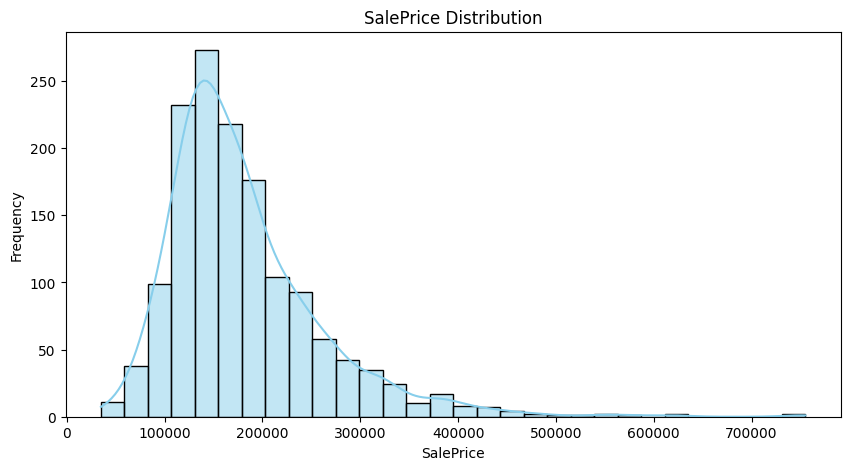

In [37]:
plt.figure(figsize=(10,5))
sns.histplot(saleprice, kde=True, bins=30, color='skyblue')
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()


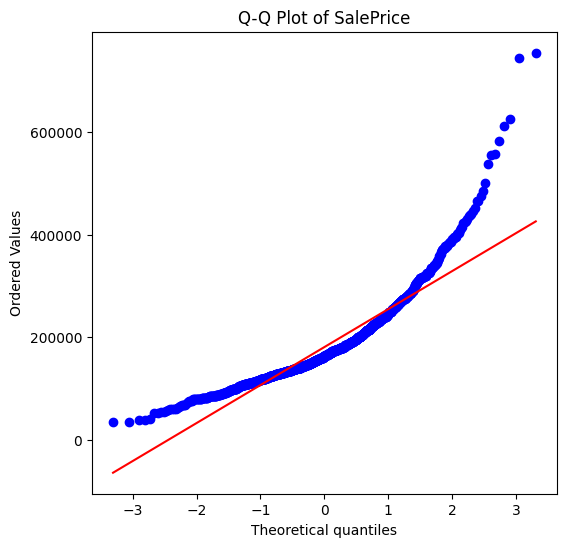

In [38]:
plt.figure(figsize=(6,6))
probplot(saleprice, dist="norm", plot=plt)
plt.title("Q-Q Plot of SalePrice")
plt.show()


Applied log transformation to SalePrice.


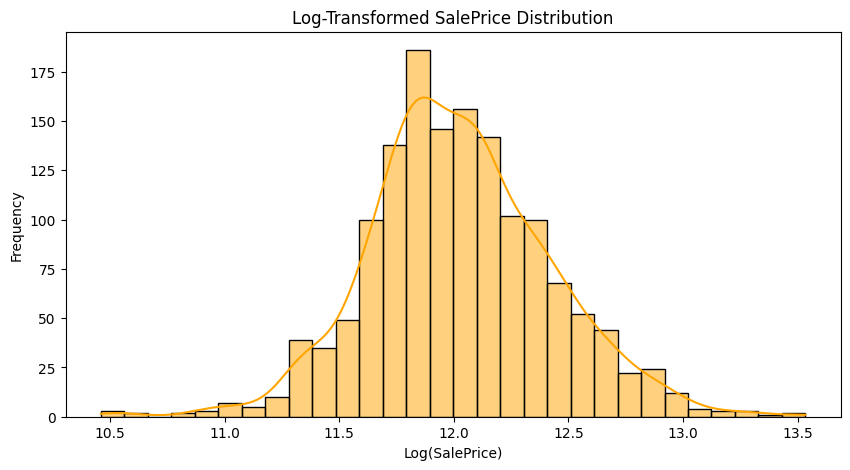

In [40]:
# Log Transformation (if skewed)
if abs(skewness_price) > 0.5:
    data['SalePrice_Log'] = np.log1p(saleprice)
    print("\nApplied log transformation to SalePrice.")

    # Check new distribution
    plt.figure(figsize=(10,5))
    sns.histplot(data['SalePrice_Log'], kde=True, bins=30, color='orange')
    plt.title("Log-Transformed SalePrice Distribution")
    plt.xlabel("Log(SalePrice)")
    plt.ylabel("Frequency")
    plt.show()

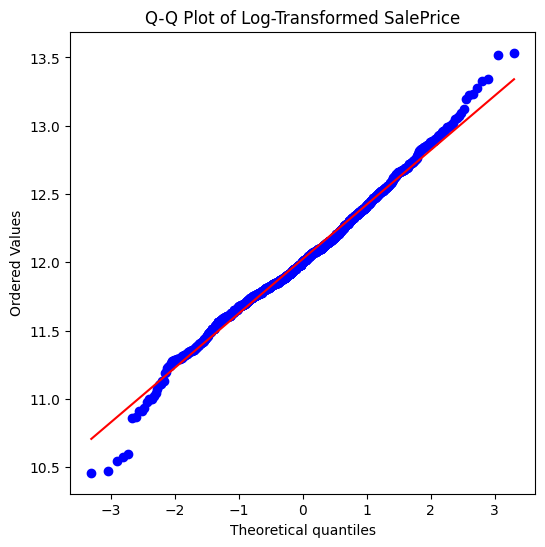

In [41]:
    # Q-Q plot
    plt.figure(figsize=(6,6))
    probplot(data['SalePrice_Log'], dist="norm", plot=plt)
    plt.title("Q-Q Plot of Log-Transformed SalePrice")
    plt.show()

Phase 2: The "Cleaning" Ritual  
Instead of guessing which points are outliers, we use the Interquartile Range (IQR).  
 The Calculation:
1. Calculate Q1 (25th percentile) and Q3 (75th percentile) for SalePrice.  
2. Find the IQR = Q3 - Q1.  
3. Define the bounds:  
Lower Bound: Q1 - 1.5 \times IQR  
Upper Bound: Q3 + 1.5 \times IQR  
 The Task: Filter your dataframe to keep only the rows where SalePrice falls between these two bounds.  
 Visualization: Create a Boxplot before and after this process to show how the "whiskers" and "fliers" (the dots) change.  

In [42]:
# Calculate Q1, Q3, and IQR for SalePrice
Q1 = data['SalePrice'].quantile(0.25)
Q3 = data['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Q1: 129975.0
Q3: 214000.0
IQR: 84025.0
Lower Bound: 3937.5
Upper Bound: 340037.5


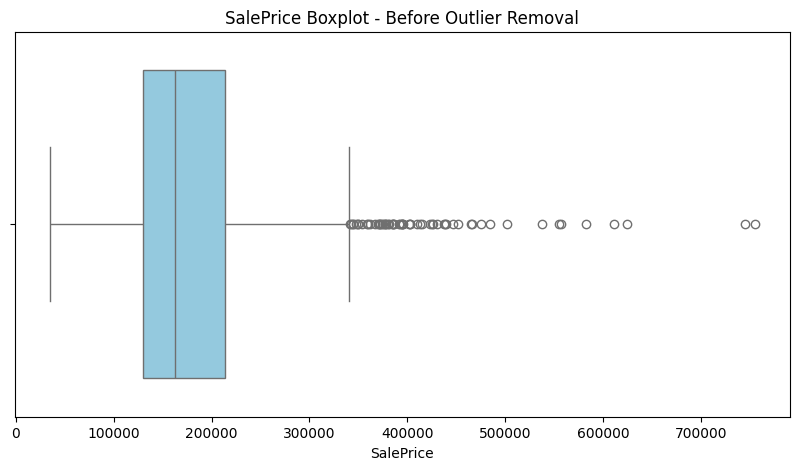

In [43]:
# Boxplot before removing outliers
plt.figure(figsize=(10,5))
sns.boxplot(x=data['SalePrice'], color='skyblue')
plt.title("SalePrice Boxplot - Before Outlier Removal")
plt.show()

In [44]:
# Filter dataframe to keep only rows within bounds
data_clean = data[(data['SalePrice'] >= lower_bound) & (data['SalePrice'] <= upper_bound)]
print(f"\nRows before cleaning: {data.shape[0]}")
print(f"Rows after cleaning: {data_clean.shape[0]}")



Rows before cleaning: 1460
Rows after cleaning: 1399


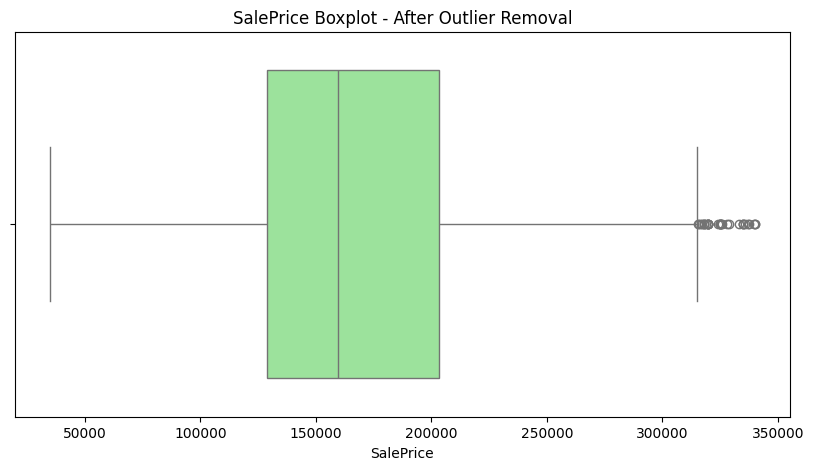

In [45]:
# Boxplot after removing outliers
plt.figure(figsize=(10,5))
sns.boxplot(x=data_clean['SalePrice'], color='lightgreen')
plt.title("SalePrice Boxplot - After Outlier Removal")
plt.show()

Phase 3: Multivariate Analysis & Visualization  
This is the heart of EDA—finding how variables dance together.  
 Correlation Matrix: Generate a heatmap of the correlation matrix.  
o Task: Identify the top 10 features most strongly correlated with SalePrice (e.g., OverallQual, GrLivArea, GarageCars).  

 Categorical Deep-Dive: Use boxplots to show the relationship between OverallQual (1–10 scale) and SalePrice.  

Neighborhood Analysis: Create a bar chart showing the average price per neighborhood. Which is the "Beverly Hills" of this dataset?  


In [46]:
df = data_clean.copy()

In [47]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_Log
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,12.317171
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,11.849405
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,12.429220


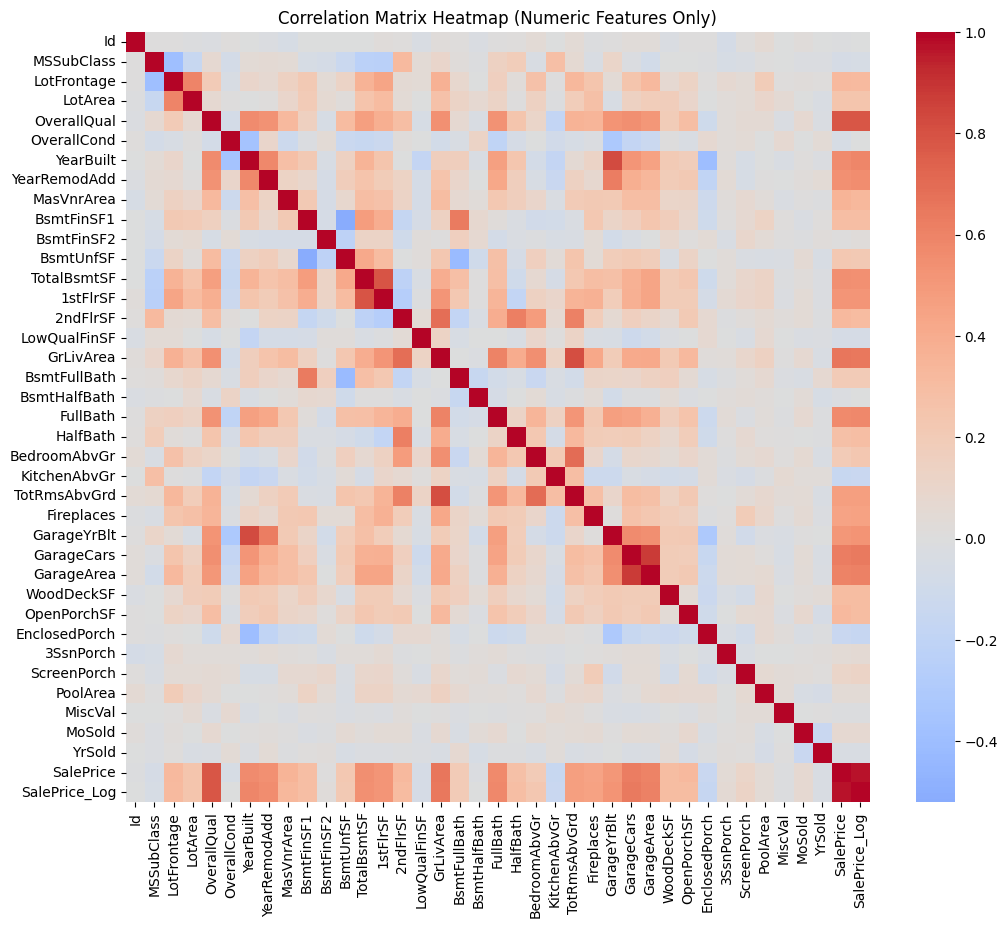

Top 10 features most correlated with SalePrice:
SalePrice_Log    0.970421
OverallQual      0.784294
GrLivArea        0.661325
GarageCars       0.628013
GarageArea       0.607230
FullBath         0.577369
YearBuilt        0.564558
TotalBsmtSF      0.543508
YearRemodAdd     0.541161
1stFlrSF         0.522785
Name: SalePrice, dtype: float64


In [53]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation only on numeric columns
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix Heatmap (Numeric Features Only)")
plt.show()

# Identify top 10 features most correlated with SalePrice
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False)[1:11]
print("Top 10 features most correlated with SalePrice:")
print(top_corr)


Categorical Deep-Dive:  
Use boxplots to show the relationship between OverallQual (1–10 scale) and SalePrice.  

/tmp/ipython-input-3251759022.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette="Blues")


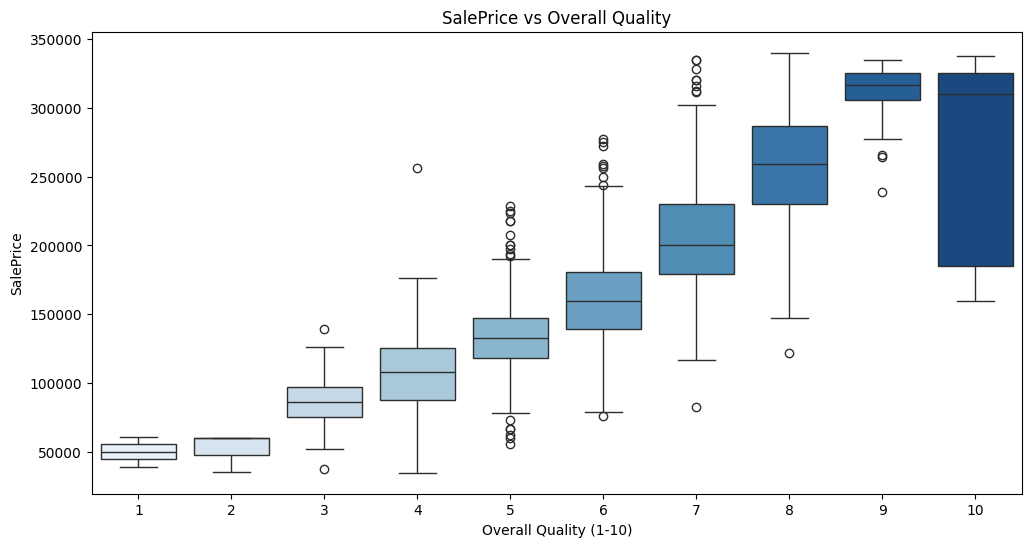

In [55]:
plt.figure(figsize=(12,6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette="Blues")
plt.title("SalePrice vs Overall Quality")
plt.xlabel("Overall Quality (1-10)")
plt.ylabel("SalePrice")
plt.show()

Neighborhood Analysis:  
Average SalePrice per Neighborhood

/tmp/ipython-input-3045487050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neighborhood_avg.index, y=neighborhood_avg.values, palette="viridis")


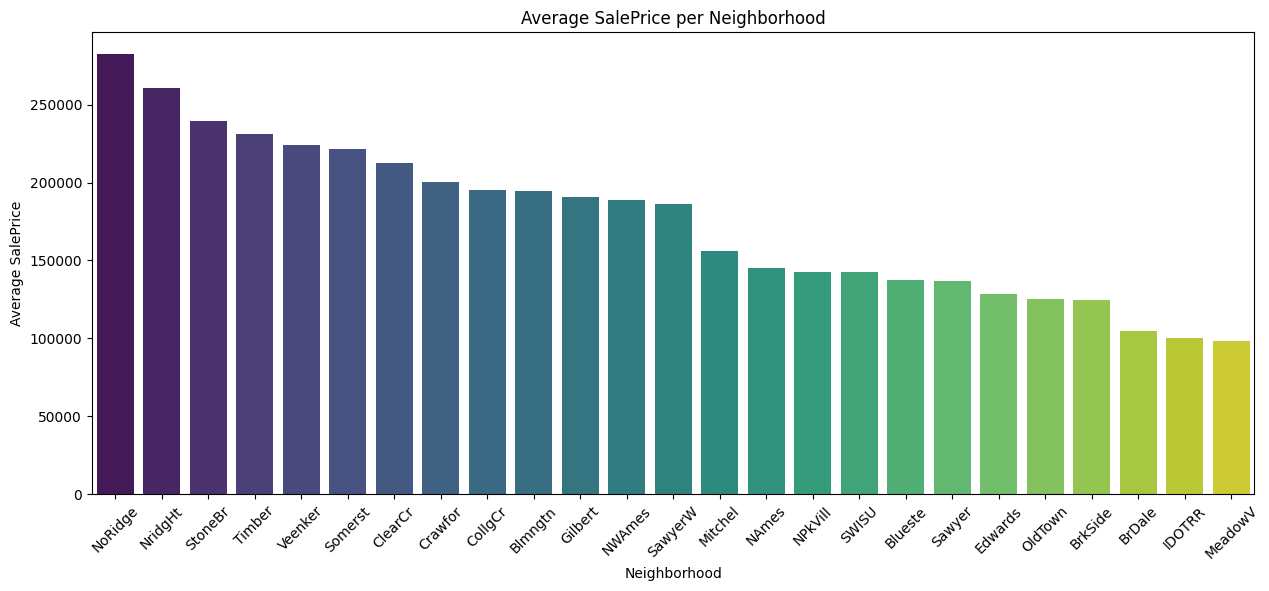


The 'Beverly Hills' of this dataset is: NoRidge with average price $282,387


In [56]:
# Calculate average SalePrice per neighborhood
neighborhood_avg = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(15,6))
sns.barplot(x=neighborhood_avg.index, y=neighborhood_avg.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Average SalePrice per Neighborhood")
plt.ylabel("Average SalePrice")
plt.xlabel("Neighborhood")
plt.show()

# Identify the "Beverly Hills" (highest average price)
top_neighborhood = neighborhood_avg.idxmax()
top_price = neighborhood_avg.max()
print(f"\nThe 'Beverly Hills' of this dataset is: {top_neighborhood} with average price ${top_price:,.0f}")


Phase 4: Final Insights & Reporting  
Summarize your findings in a "Managerial Report" format:  
1. Top 3 Drivers: What are the three most important factors in determining a house's price?  
2. Anomaly Report: Which features had the most missing data, and how might that affect a future model?  
3. Visual Summary: Include your 4 most impactful charts.  

In [57]:
# Using numeric correlations from Phase 3
top_corr_features = top_corr.index.tolist()
print("Top 3 numeric drivers of SalePrice:")
print(top_corr_features[:3])


Top 3 numeric drivers of SalePrice:
['SalePrice_Log', 'OverallQual', 'GrLivArea']


In [58]:
# Check missing values
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]  # only show features with missing data
missing_data_percent = (missing_data / df.shape[0] * 100).round(2)

missing_report = pd.DataFrame({'Missing Count': missing_data, 'Missing %': missing_data_percent})
print("Features with missing data:")
missing_report.head(10)

Features with missing data:


,Missing Count,Missing %
PoolQC,1393,99.57
MiscFeature,1345,96.14
Alley,1308,93.50
Fence,1122,80.20
MasVnrType,861,61.54
FireplaceQu,689,49.25
LotFrontage,256,18.30
GarageQual,81,5.79
GarageYrBlt,81,5.79
GarageFinish,81,5.79


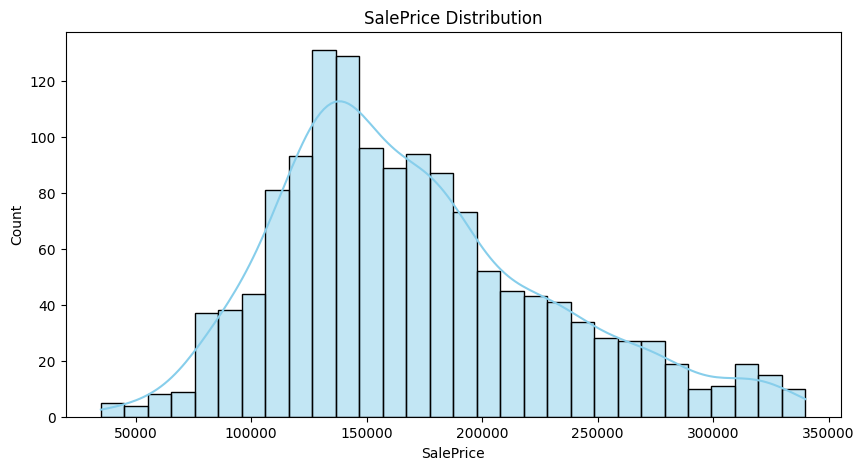

In [59]:
# Chart 1: SalePrice Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice'], kde=True, bins=30, color='skyblue')
plt.title("SalePrice Distribution")
plt.show()

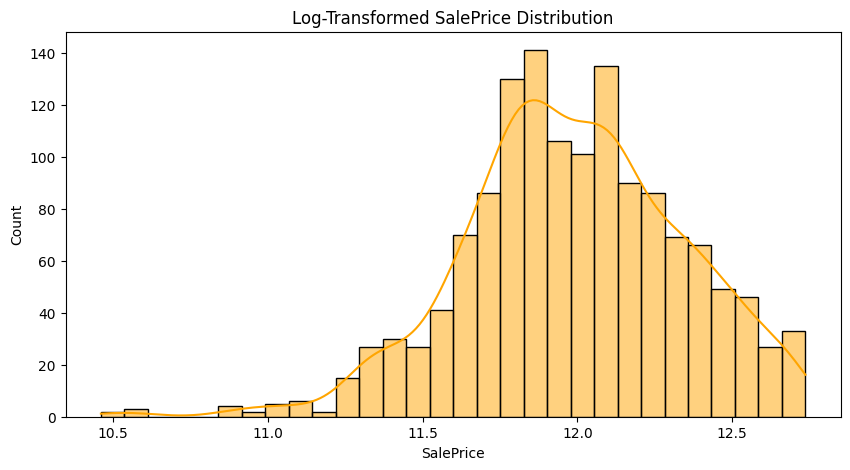

In [60]:
# Chart 2: Log-Transformed SalePrice Distribution (if skewed)
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['SalePrice']), kde=True, bins=30, color='orange')
plt.title("Log-Transformed SalePrice Distribution")
plt.show()

/tmp/ipython-input-2276093231.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette="Blues")


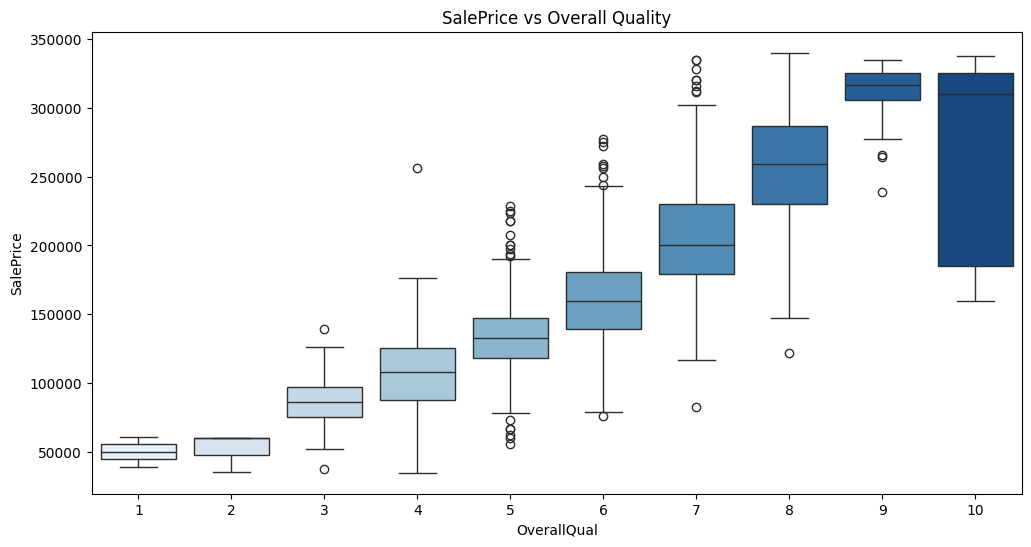

In [61]:
# Chart 3: SalePrice vs OverallQual

plt.figure(figsize=(12,6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette="Blues")
plt.title("SalePrice vs Overall Quality")
plt.show()

/tmp/ipython-input-3299766173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neighborhood_avg.index, y=neighborhood_avg.values, palette="viridis")


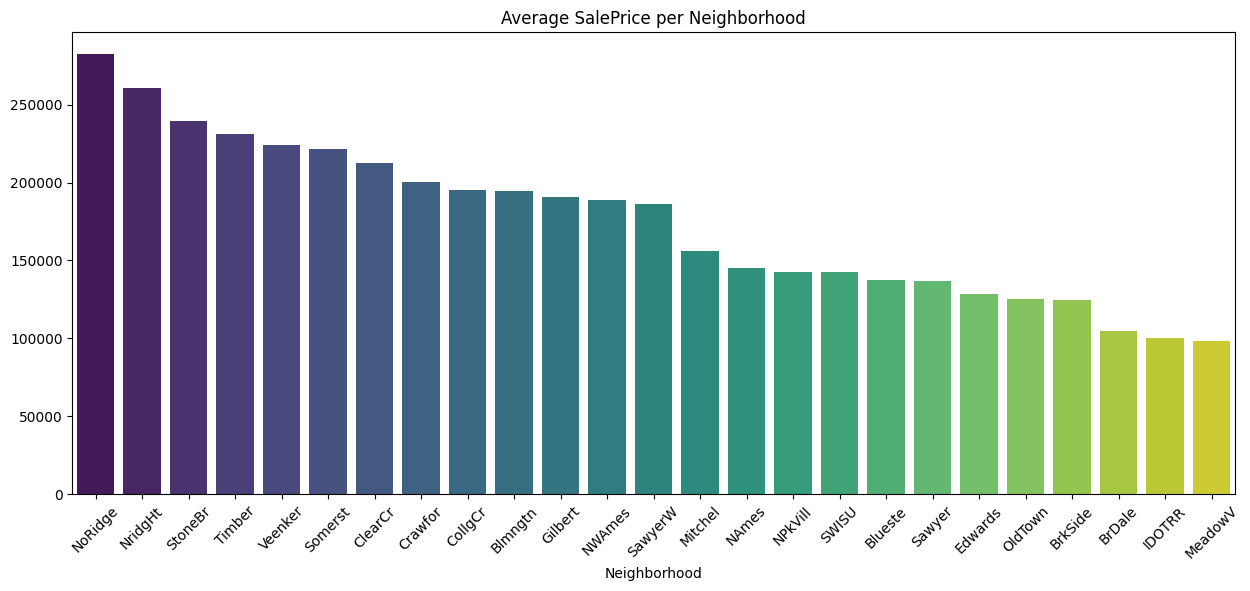

In [62]:
# Chart 4: Average SalePrice per Neighborhood

neighborhood_avg = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(15,6))
sns.barplot(x=neighborhood_avg.index, y=neighborhood_avg.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Average SalePrice per Neighborhood")
plt.show()

In [65]:
print("\n EDA Complete: Dataset inspected, cleaned, visualized, and key insights summarized.")


 EDA Complete: Dataset inspected, cleaned, visualized, and key insights summarized.
